# All-probe Bombcell dashboard (ROI-aware)

This notebook loads **all probes simultaneously** and builds ROI-aware tables/plots.

## How to use `IN_ROI` / `OUTSIDE_ROI`
1. Set per-probe ROI length in `ROI_END_UM_BY_PROBE` (distance from probe tip in microns).
2. Units with `distance_from_tip_um <= ROI_END_UM_BY_PROBE[probe]` are labeled `IN_ROI`.
3. Units above that cutoff are labeled `OUTSIDE_ROI`.
4. If a probe has no ROI value (`None`), units are labeled `ROI_NOT_SET`.


In [2]:
from pathlib import Path
import re
from typing import Any, Dict
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
import numpy as np
import pandas as pd
import importlib
import subprocess
import os
from dotenv import load_dotenv

plt.rcParams['figure.dpi'] = 120

import bombcell as bc

# ============= Load in configuration and helper functions =============
# Add MOUSE_NAME directory to path
mouse_dir = Path().resolve().parent.parent  # notebook in analyze_bc_results/
print("Notebook:", Path().resolve())
print("Added to sys.path:", mouse_dir)
print("Exists:", mouse_dir.exists())
print("Contents:", [p.name for p in mouse_dir.iterdir()])
sys.path.append(str(Path().resolve().parent))  # adds .../mice/Reach15

print("CWD:", Path().resolve())
print("sys.path[0:5]:", sys.path[0:5])
print("Has Reach15/grant_config.py?:", (Path().resolve().parent / "grant_config.py").exists())
print("Has Reach15/helper_func/grant_config.py?:", (Path().resolve().parent / "helper_func" / "grant_config.py").exists())

import helper_func.prep_data as data_prep
import helper_func.nwb_data_prep as prep
import helper_func.post_analysis_setup as post_analysis
import helper_func.load_ch_geometry as ch_geometry
from helper_func.grant_config import load_grant_config
from helper_func.post_analysis_setup import load_post_analysis_context

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
# plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


Notebook: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
Added to sys.path: C:\Users\user\Documents\github\bombcell\mice
Exists: True
Contents: ['Reach15']
CWD: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
sys.path[0:5]: ['c:\\Users\\user\\anaconda3\\envs\\bombcell\\python311.zip', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\DLLs', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\Lib', 'c:\\Users\\user\\anaconda3\\envs\\bombcell', '']
Has Reach15/grant_config.py?: False
Has Reach15/helper_func/grant_config.py?: True
pca_data_prep path: C:\Users\user\Documents\github\bombcell\mice\Reach15\helper_func\nwb_data_prep.py


### Load data from .env

In [3]:
session_data_dic = prep.load_env()
session_data_dic.keys()

MOUSE loaded: Reach15




-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- First Neuropixels File --
NP_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE loaded: 20260129
SESSION loaded: session003
BOMBCELL loaded: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG loaded: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG loaded: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG loaded: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json


-- Second Neuropixels File --
NP_FILE loaded: Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32
NWB_FILE loaded: NA
DATE_01 loaded: 20260129
SESSION_01 loaded: session004
BOMBCELL_01 loaded: NA
PROBE_A_CH_CONFIG_01 loaded: NA
PROBE_C_CH_CONFIG_01 loaded: NA
PROBE_D_CH_CONFIG_01 loa

dict_keys(['MOUSE', 'BEHAVIORAL_FOLDER', 'NP_FILE', 'DATE', 'SESSION', 'BOMBCELL', 'NWB_FILE', 'PROBE_A_CH_CONFIG', 'PROBE_C_CH_CONFIG', 'PROBE_D_CH_CONFIG', 'NP_FILE_01', 'DATE_01', 'SESSION_01', 'BOMBCELL_01', 'NWB_FILE_01', 'PROBE_A_CH_CONFIG_01', 'PROBE_C_CH_CONFIG_01', 'PROBE_D_CH_CONFIG_01', 'NP_FILE_02', 'DATE_02', 'SESSION_02', 'BOMBCELL_02', 'NWB_FILE_02', 'PROBE_A_CH_CONFIG_02', 'PROBE_C_CH_CONFIG_02', 'PROBE_D_CH_CONFIG_02'])

#### =========================================================
## STEP 1: Select Neuropixel session to analyze
#### =========================================================

In [5]:
SESSION_TO_ANALYZE = 3

MOUSE, BEHAVIORAL_FOLDER,PROBE_A_CH_CONFIG, PROBE_C_CH_CONFIG, PROBE_D_CH_CONFIG, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL= prep.session_to_analyze(
                                                                                        session_data_dic['MOUSE'], session_data_dic['BEHAVIORAL_FOLDER'], 
                                                                                        session_data_dic['NP_FILE'],session_data_dic['NWB_FILE'] ,session_data_dic['DATE'], session_data_dic['SESSION'],session_data_dic['BOMBCELL'],session_data_dic['PROBE_A_CH_CONFIG'], session_data_dic['PROBE_C_CH_CONFIG'], session_data_dic['PROBE_D_CH_CONFIG'],
                                                                                        session_data_dic['NP_FILE_01'], session_data_dic['NWB_FILE_01'], session_data_dic['DATE_01'], session_data_dic['SESSION_01'],session_data_dic['BOMBCELL_01'],session_data_dic['PROBE_A_CH_CONFIG_01'], session_data_dic['PROBE_C_CH_CONFIG_01'], session_data_dic['PROBE_D_CH_CONFIG_01'],
                                                                                        session_data_dic['NP_FILE_02'], session_data_dic['NWB_FILE_02'], session_data_dic['DATE_02'], session_data_dic['SESSION_02'],session_data_dic['BOMBCELL_02'],session_data_dic['PROBE_A_CH_CONFIG_02'], session_data_dic['PROBE_C_CH_CONFIG_02'], session_data_dic['PROBE_D_CH_CONFIG_02'],
                                                                                        session_selection=SESSION_TO_ANALYZE
                                                                                    )
MOUSE, BEHAVIORAL_FOLDER, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL
                                                               


SESSION SELECTION:

NP_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
NWB_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
DATE: 20260201
SESSION: session007
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260304_1536
PROBE_A_CH_CONFIG: probeA_SIM_IP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_C_CH_CONFIG: probeC_MoP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_D_CH_CONFIG: probeD_VaL__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json


('Reach15',
 'grant_reach15_swingDoor-christie',
 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 '20260201',
 'session007',
 'bombcell_batch_20260304_1536')

### Set up bombcell context for this session

In [6]:
BOMBCELL_ROOT_FOR_AUTO_BUILD, NWB_PATH, CONFIG_FILE, SESSION_NAME = data_prep.set_bc_paths(
session_data_dic, MOUSE,NWB_FILE, NP_FILE, BOMBCELL, BEHAVIORAL_FOLDER, DATE, SESSION, SESSION_TO_ANALYZE
)


Baseline trials index path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy
Washout trials index path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy
Optical stim trials index path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy

AUTO-GENERATED SESSION CONFIG

Session selection: 3
Mouse root: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results\mice\Reach15
Recording name: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
Wrote config: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results\mice\Reach15\configs\grant_recording_config_20260201_session

In [7]:
# Configuration - CHANGE THESE VALUES FOR YOUR DATA
BOMBCELL = session_data_dic['BOMBCELL']
NP_FILE = session_data_dic['NP_FILE']
staging_root = fr'H:\Grant\Neuropixels\Kilosort_Recordings\{NP_FILE}\bombcell\{BOMBCELL}'
TARGET_PROBE = 'A' 

# Optional: Set to True to see detailed information about each unit's classification
VERBOSE = True

### Set Neuropixel Root Directory

In [8]:
# Construct the recording folder path
root_recording_folder = fr"H:\Grant\Neuropixels\Kilosort_Recordings\{session_data_dic['NP_FILE']}"  # Replace with actual root path
recording_folder = os.path.join(root_recording_folder, "Record Node 103", "experiment1", "recording1", "continuous")

#root_behavior_path = fr"G:\Grant\neuropixels\behavioral_recordings\{BEHAVIORAL_FOLDER}"
# Example values (replace as needed)A
root_behavior_path = fr"G:\Grant\behavior_data\DLC_net\{session_data_dic['BEHAVIORAL_FOLDER']}"
behavioral_folder = os.path.join(root_behavior_path, session_data_dic['DATE'] ,session_data_dic['SESSION'])
print(f'behavioral_folder: {behavioral_folder}')
# Check if the recording folder exists
if not os.path.exists(recording_folder):
    raise FileNotFoundError(f"Recording folder not found: {recording_folder}")
else:
    print("Neuropixel Recording folder found:", recording_folder)


behavioral_folder: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\20260129\session003
Neuropixel Recording folder found: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\Record Node 103\experiment1\recording1\continuous


### Load in all bombcell configuration and context for this session

In [9]:
# staging_root, save_subdir = mode_to_roots[RUN_MODE]
ks_dir = Path(root_recording_folder) / f'kilosort4_{TARGET_PROBE}'
save_path = ks_dir / 'bombcell' 

print('Kilosort directory:', ks_dir)
print('Bombcell save path:', save_path)
print()
print('TSV file will be saved to:', ks_dir / 'cluster_bc_classificationReason.tsv')

# Load the config 
ctx = load_post_analysis_context(CONFIG_FILE)

probe_letters = list(ctx['probeLetters'])
config_probe_letters = probe_letters

print('staging_root:', staging_root)
print('probes:', probe_letters)

Kilosort directory: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A
Bombcell save path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A\bombcell

TSV file will be saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A\cluster_bc_classificationReason.tsv
staging_root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130
probes: ['A', 'B', 'C', 'D', 'E', 'F']


In [10]:
# Configuration - CHANGE THESE VALUES FOR YOUR DATA
TARGET_PROBE = 'A'
BOMBCELL = session_data_dic['BOMBCELL']
NP_FILE = session_data_dic['NP_FILE']
staging_root = fr'H:\Grant\Neuropixels\Kilosort_Recordings\{NP_FILE}\bombcell\{BOMBCELL}'
ks_dir = Path(staging_root) / f'kilosort4_{TARGET_PROBE}'
save_path = ks_dir / 'bombcell'

probe_dirs = {}
missing_probes = []
for probe in probe_letters:
    ks_dir = Path(staging_root) / f'kilosort4_{probe}'
    save_path = ks_dir
    probe_dirs[probe] = save_path
    print(f'Loading probe {probe} from ks_dir: {ks_dir}')
    if not save_path.exists():
        print(f'Missing bombcell save_path for probe {probe}: {save_path}')
        missing_probes.append(probe)
        continue
probe_dirs


Loading probe A from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_A
Loading probe B from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_B
Loading probe C from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_C
Loading probe D from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_D
Loading probe E from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_E
Loading probe F from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session0

{'A': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_A'),
 'B': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_B'),
 'C': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_C'),
 'D': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_D'),
 'E': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_E'),
 'F': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/

# ======================================================================================

In [11]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bombcell as bc

analysis_dir = Path.cwd().resolve()
sys.path.insert(0, str(analysis_dir))


# IMPORTANT: set your per-probe ROI extents from TIP (um)
# Example from issue: Probe B NP1.0 ROI is tip->950um
# EVERY PROBE INCLUDES ~200um PADDING BEYOND ROI END
# ----------------------------
probeA_IP_um = (0, 850)        # Interposed nucleus
probeA_SIM_um = (851, 3250)    # Simplex lobule

ROI_END_UM_BY_PROBE = {
    'A': 3450, # 3250um + 200um padding 
    'B': 950, # 750um + 200um padding
    'C': 1800, # 1600um + 200um padding
    'D': 1400, # 1200um + 200um padding
    'E': 800, # 600um + 200um padding
    'F': 1120, # 920um + 200um padding
}
TIP_POSITION_BY_PROBE = {
    'A': 'min_y', 'B': 'min_y', 'C': 'min_y',
    'D': 'min_y', 'E': 'min_y', 'F': 'min_y',
}

PROBE_TO_REGION = {
    "B": "PG",
    "C": "MoP",
    "D": "VaL",
    "E": "SnR",
    "F": "RN",
}

TIP_POSITION = "min_y"  # min_y is the CORRECT choice for probes. 
PROBES = ["A", "B", "C", "D", "E", "F"]


# Load the config 
ctx = load_post_analysis_context(CONFIG_FILE)

probe_letters = list(ctx['probeLetters'])
probe_letters_config = probe_letters

print('staging_root:', staging_root)
print('probes:', probe_letters)


staging_root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130
probes: ['A', 'B', 'C', 'D', 'E', 'F']


### Change what probes will be processesed
- if you want to proccess all probes at once simply set:
    - manual_probe_letters = None

In [12]:

# either set probes or set to NONE to use all probes from config
manually_set_probes = None # -> ["A","B","C"]
# manually_set_probes = None

# --------------------------------------------------------------------------
# This is a workaround if for some reason a probe is giving trouble and you want to skip it , or the probe doesnt exist

if manually_set_probes is not None:
    probe_letters = manually_set_probes
    print(f'Using manual probe letters: {probe_letters}\n')
    print('To use all probes from config, set manually_set_probes = None')
else:
    probe_letters = probe_letters_config
    print(f'Using probe letters from config: {probe_letters}')
# --------------------------------------------------------------------------


Using probe letters from config: ['A', 'B', 'C', 'D', 'E', 'F']


## Load all probes and attach ROI labels + classification + reason flags


In [ ]:


all_units = []
missing_probes = []

for probe in probe_letters:
    ks_dir = Path(staging_root) / f'kilosort4_{probe}'
    save_path = ks_dir / 'bombcell'
    print(f'Loading probe {probe} from ks_dir: {ks_dir}')
    if not save_path.exists():
        print(f'Missing bombcell save_path for probe {probe}: {save_path}')
        missing_probes.append(probe)
        continue

    param, quality_metrics, _ = bc.load_bc_results(str(save_path))
    unit_type, unit_type_string = bc.qm.get_quality_unit_type(param, quality_metrics)

    qm_df = pd.DataFrame(quality_metrics).copy()
    qm_df['probe'] = probe
    qm_df['ks_dir'] = str(ks_dir)
    qm_df['save_path'] = str(save_path)
    qm_df['bombcell_label'] = unit_type_string
    qm_df['unit_index'] = np.arange(len(qm_df))

    if 'cluster_id' not in qm_df.columns:
        qm_df['cluster_id'] = qm_df['unit_index']

    roi_end = ROI_END_UM_BY_PROBE.get(probe, None)
    if roi_end is None:
        qm_df['distance_from_tip_um'] = np.nan
        qm_df['roi_label'] = 'ROI_NOT_SET'
    else:
        qm_df = post_analysis.label_units_by_tip_distance(
            quality_metrics=qm_df,
            ks_dir=ks_dir,
            roi_end_um=float(roi_end),
            tip_position=TIP_POSITION_BY_PROBE.get(probe, 'min_y'),
            in_label='IN_ROI',
            out_label='OUTSIDE_ROI',
        )

    # Build reason flags from Bombcell qm table (boolean columns)
    qm_table = bc.make_qm_table(quality_metrics, param, unit_type_string)
    bool_cols = [c for c in qm_table.columns if qm_table[c].dtype == bool]
    reason_tokens = []
    for _, row in qm_table[bool_cols].iterrows():
        hits = [c for c in bool_cols if bool(row[c])]
        reason_tokens.append(hits)

    qm_df['reason_tokens'] = reason_tokens
    qm_df['n_reason_flags'] = qm_df['reason_tokens'].apply(len)

    all_units.append(qm_df)

if len(all_units) == 0:
    raise RuntimeError('No probe outputs were loaded. Check RUN_MODE/staging root and that bombcell outputs exist.')

all_df = pd.concat(all_units, ignore_index=True)
print('Loaded units:', len(all_df))
print('Missing probes (no save_path):', missing_probes)
print(all_df[['probe','bombcell_label','roi_label']].head())


Loading probe A from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_A


## Unified all-probe dataframe views


In [13]:
all_df

,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,peak1ToPeak2Ratio,...,probe,ks_dir,save_path,bombcell_label,unit_index,cluster_id,distance_from_tip_um,roi_label,reason_tokens,n_reason_flags
0,0,2230.0,2.0,1.0,200.000000,0.066172,0.020748,0.330603,0.330603,0.555833,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,0,0,465.0,IN_ROI,[],0
1,1,8462.0,3.0,2.0,433.333333,0.044273,0.192722,0.324805,1.557996,4.796711,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,NOISE,1,1,450.0,IN_ROI,[],0
2,2,2013.0,2.0,1.0,166.666667,0.053613,0.033056,0.322155,0.322155,0.780877,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,2,2,465.0,IN_ROI,[],0
3,3,32199.0,2.0,1.0,533.333333,0.045540,0.179444,0.243429,0.243429,0.737153,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,3,3,450.0,IN_ROI,[],0
4,4,83405.0,1.0,1.0,466.666667,0.038150,0.129491,0.054460,2.484294,45.616913,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,NON-SOMA,4,4,450.0,IN_ROI,[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5529,1481,55011.0,1.0,1.0,333.333333,0.032824,0.085167,0.534811,0.534811,0.159009,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1481,1481,3820.0,OUTSIDE_ROI,[],0
5530,1482,7811.0,1.0,1.0,233.333333,0.020806,0.018716,0.365141,0.365141,0.128495,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1482,1482,3820.0,OUTSIDE_ROI,[],0
5531,1483,605.0,2.0,1.0,133.333333,0.019519,0.061551,0.405629,0.545139,1.343935,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1483,1483,3580.0,OUTSIDE_ROI,[],0
5532,1484,2579.0,1.0,1.0,233.333333,0.056551,0.035401,0.359945,0.359945,0.083254,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1484,1484,3800.0,OUTSIDE_ROI,[],0


In [14]:
# modify to sort by brain region

summary_probe_roi_class = (
    all_df.groupby(['probe', 'roi_label', 'bombcell_label'])
    .size()
    .rename('n_units')
    .reset_index()
)
display(summary_probe_roi_class.sort_values(['probe', 'roi_label', 'bombcell_label']).head(200))

pivot_probe_class = all_df.pivot_table(index='probe', columns='bombcell_label', values='cluster_id', aggfunc='count', fill_value=0)
display(pivot_probe_class)

pivot_probe_roi = all_df.pivot_table(index='probe', columns='roi_label', values='cluster_id', aggfunc='count', fill_value=0)
display(pivot_probe_roi)


,probe,roi_label,bombcell_label,n_units
0,A,IN_ROI,GOOD,1
1,A,IN_ROI,MUA,268
2,A,IN_ROI,NOISE,492
3,A,IN_ROI,NON-SOMA,200
4,B,IN_ROI,GOOD,39
5,B,IN_ROI,MUA,34
6,B,IN_ROI,NOISE,69
7,B,IN_ROI,NON-SOMA,37
8,B,OUTSIDE_ROI,GOOD,85
9,B,OUTSIDE_ROI,MUA,54


bombcell_label,GOOD,MUA,NOISE,NON-SOMA
probe,,,,
A,1,268,492,200
B,124,88,153,166
C,7,238,395,49
D,45,522,253,81
E,42,488,149,287
F,45,653,148,640


roi_label,IN_ROI,OUTSIDE_ROI
probe,,
A,961,0
B,179,352
C,689,0
D,901,0
E,173,793
F,337,1149


## ROI-aware plots across all probes


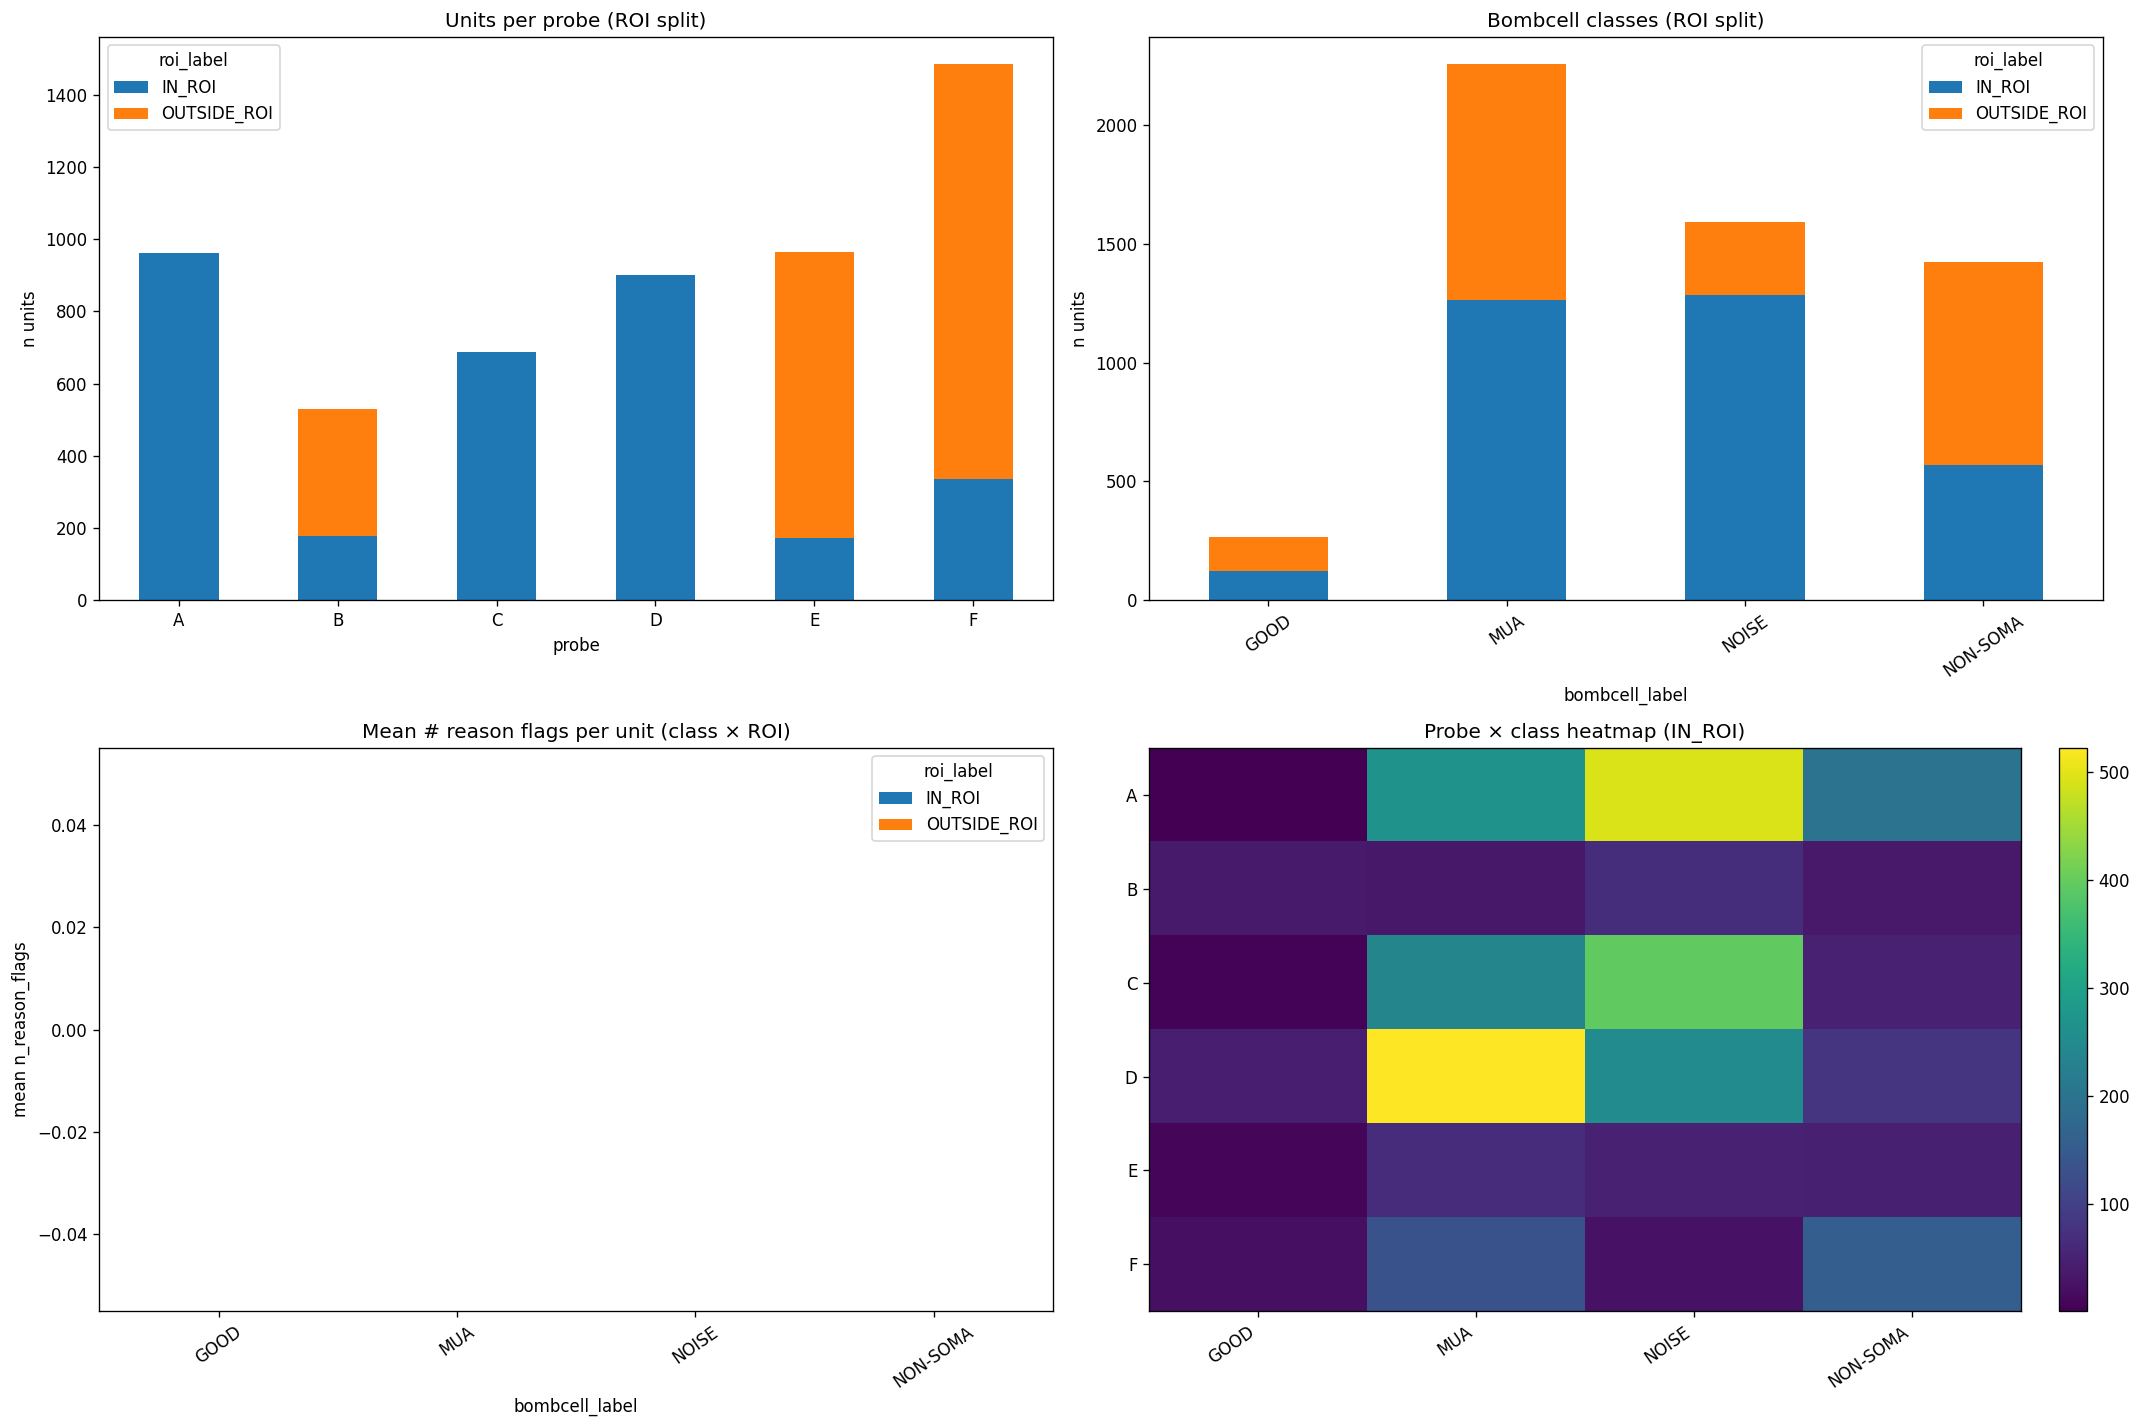

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Units per probe split by ROI label
probe_roi = all_df.pivot_table(index='probe', columns='roi_label', values='cluster_id', aggfunc='count', fill_value=0)
probe_roi.plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title('Units per probe (ROI split)')
axes[0,0].set_ylabel('n units')
axes[0,0].tick_params(axis='x', rotation=0)

# 2) Units per class split by ROI label
class_roi = all_df.pivot_table(index='bombcell_label', columns='roi_label', values='cluster_id', aggfunc='count', fill_value=0)
class_roi.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('Bombcell classes (ROI split)')
axes[0,1].set_ylabel('n units')
axes[0,1].tick_params(axis='x', rotation=35)

# 3) Mean reason flags per class and ROI
mean_flags = all_df.groupby(['bombcell_label','roi_label'])['n_reason_flags'].mean().unstack(fill_value=0)
mean_flags.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Mean # reason flags per unit (class × ROI)')
axes[1,0].set_ylabel('mean n_reason_flags')
axes[1,0].tick_params(axis='x', rotation=35)

# 4) Probe × class heatmap for IN_ROI only (or fallback ALL)
in_roi = all_df[all_df['roi_label'] == 'IN_ROI']
plot_df = in_roi if len(in_roi) > 0 else all_df
heat = plot_df.pivot_table(index='probe', columns='bombcell_label', values='cluster_id', aggfunc='count', fill_value=0)
im = axes[1,1].imshow(heat.to_numpy(), aspect='auto')
axes[1,1].set_xticks(np.arange(len(heat.columns)))
axes[1,1].set_xticklabels(list(heat.columns), rotation=35, ha='right')
axes[1,1].set_yticks(np.arange(len(heat.index)))
axes[1,1].set_yticklabels(list(heat.index))
axes[1,1].set_title('Probe × class heatmap (' + ('IN_ROI' if len(in_roi)>0 else 'ALL units') + ')')
plt.colorbar(im, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Reason-level plots with ROI as a key dimension


In [16]:
from collections import Counter
# import display package for dataframes


# explode reasons for long-form reason table
reason_rows = []
for _, row in all_df.iterrows():
    for r in row['reason_tokens']:
        reason_rows.append({'probe': row['probe'], 'roi_label': row['roi_label'], 'bombcell_label': row['bombcell_label'], 'reason': r})
reason_df = pd.DataFrame(reason_rows)
# display the reason_df 
display(reason_df)
display(all_df)

if len(reason_df) == 0:
    print('No reason flags available in reason_df')
else:
    # top reasons overall
    top_reasons = reason_df['reason'].value_counts().head(12).index
    rr = reason_df[reason_df['reason'].isin(top_reasons)]

    fig, axes = plt.subplots(1, 3, figsize=(23, 6))

    # A) top reasons by ROI
    a = rr.groupby(['reason','roi_label']).size().unstack(fill_value=0).loc[top_reasons]
    a.plot(kind='barh', stacked=True, ax=axes[0])
    axes[0].set_title('Top reason counts (ROI split)')
    axes[0].set_xlabel('count')

    # B) top reasons by probe (stacked)
    b = rr.groupby(['reason','probe']).size().unstack(fill_value=0).loc[top_reasons]
    b.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('Top reason counts by probe')
    axes[1].tick_params(axis='x', rotation=60)

    # C) reason heatmap for IN_ROI (or OUTSIDE fallback)
    focus = rr[rr['roi_label']=='IN_ROI']
    if len(focus)==0:
        focus = rr[rr['roi_label']=='OUTSIDE_ROI']
    h = focus.pivot_table(index='reason', columns='probe', values='bombcell_label', aggfunc='count', fill_value=0)
    h = h.loc[h.sum(axis=1).sort_values(ascending=False).head(12).index]
    im = axes[2].imshow(h.to_numpy(), aspect='auto')
    axes[2].set_yticks(np.arange(len(h.index)))
    axes[2].set_yticklabels(list(h.index))
    axes[2].set_xticks(np.arange(len(h.columns)))
    axes[2].set_xticklabels(list(h.columns))
    axes[2].set_title('Reason heatmap in ROI focus set')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


""


,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,peak1ToPeak2Ratio,...,probe,ks_dir,save_path,bombcell_label,unit_index,cluster_id,distance_from_tip_um,roi_label,reason_tokens,n_reason_flags
0,0,2230.0,2.0,1.0,200.000000,0.066172,0.020748,0.330603,0.330603,0.555833,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,0,0,465.0,IN_ROI,[],0
1,1,8462.0,3.0,2.0,433.333333,0.044273,0.192722,0.324805,1.557996,4.796711,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,NOISE,1,1,450.0,IN_ROI,[],0
2,2,2013.0,2.0,1.0,166.666667,0.053613,0.033056,0.322155,0.322155,0.780877,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,2,2,465.0,IN_ROI,[],0
3,3,32199.0,2.0,1.0,533.333333,0.045540,0.179444,0.243429,0.243429,0.737153,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,3,3,450.0,IN_ROI,[],0
4,4,83405.0,1.0,1.0,466.666667,0.038150,0.129491,0.054460,2.484294,45.616913,...,A,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,NON-SOMA,4,4,450.0,IN_ROI,[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5529,1481,55011.0,1.0,1.0,333.333333,0.032824,0.085167,0.534811,0.534811,0.159009,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1481,1481,3820.0,OUTSIDE_ROI,[],0
5530,1482,7811.0,1.0,1.0,233.333333,0.020806,0.018716,0.365141,0.365141,0.128495,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1482,1482,3820.0,OUTSIDE_ROI,[],0
5531,1483,605.0,2.0,1.0,133.333333,0.019519,0.061551,0.405629,0.545139,1.343935,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1483,1483,3580.0,OUTSIDE_ROI,[],0
5532,1484,2579.0,1.0,1.0,233.333333,0.056551,0.035401,0.359945,0.359945,0.083254,...,F,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,MUA,1484,1484,3800.0,OUTSIDE_ROI,[],0


No reason flags available in reason_df


## Individual-unit + probe-level drill-down (ROI-aware)


In [17]:
# Pick any probe and class; then inspect units + reason flags
DRILL_PROBE = 'A'
BRAIN_REGION = 'SIM'

DRILL_CLASS = None  # e.g. 'MUA', 'GOOD', 'NOISE', 'NON-SOMA'; None keeps all
DRILL_ROI = 'IN_ROI'  # IN_ROI | OUTSIDE_ROI | ROI_NOT_SET | None
BRAIN_REGION = 'SIM'

sub = all_df[all_df['probe'] == DRILL_PROBE].copy()
if BRAIN_REGION is not None:
    sub = sub[sub['brain_region'] == BRAIN_REGION]
    
if DRILL_CLASS is not None:
    sub = sub[sub['bombcell_label'].astype(str).str.contains(DRILL_CLASS, regex=False)]
if DRILL_ROI is not None:
    sub = sub[sub['roi_label'] == DRILL_ROI]

print('n units in drill subset:', len(sub))
display(sub[['probe','cluster_id','bombcell_label','roi_label','distance_from_tip_um','n_reason_flags']].head(100))


KeyError: 'brain_region'

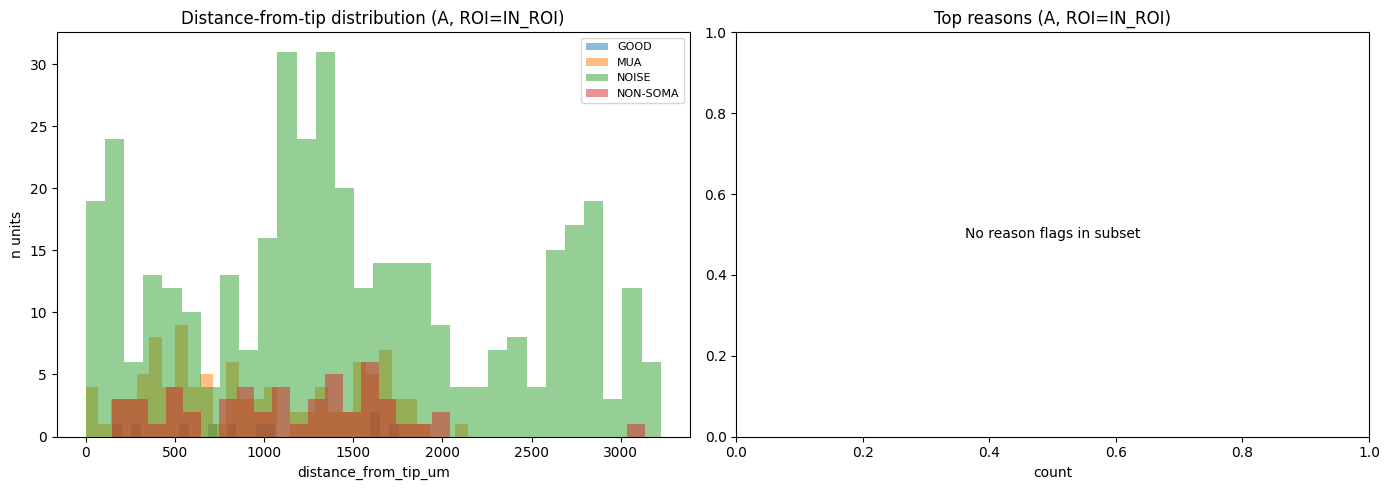

In [22]:
if len(sub) == 0:
    print('Drill subset empty. Adjust DRILL_* filters.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # distance distribution by class within drill subset
    if sub['distance_from_tip_um'].notna().any():
        for label, grp in sub.groupby('bombcell_label'):
            vals = grp['distance_from_tip_um'].dropna().to_numpy()
            if len(vals) > 0:
                axes[0].hist(vals, bins=30, alpha=0.5, label=str(label))
        axes[0].set_title(f'Distance-from-tip distribution ({DRILL_PROBE}, ROI={DRILL_ROI})')
        axes[0].set_xlabel('distance_from_tip_um')
        axes[0].set_ylabel('n units')
        axes[0].legend(fontsize=8)
    else:
        axes[0].text(0.5,0.5,'No distance data for this subset',ha='center',va='center')

    # top reasons in drill subset
    from collections import Counter
    c = Counter(r for row in sub['reason_tokens'] for r in row)
    if c:
        top = c.most_common(15)
        labs = [k for k,_ in top][::-1]
        vals = [v for _,v in top][::-1]
        axes[1].barh(labs, vals)
    else:
        axes[1].text(0.5,0.5,'No reason flags in subset',ha='center',va='center')
    axes[1].set_title(f'Top reasons ({DRILL_PROBE}, ROI={DRILL_ROI})')
    axes[1].set_xlabel('count')

    plt.tight_layout()
    plt.show()


## Optional export


In [13]:
out_csv = Path(staging_root) / f'all_probes_{RUN_MODE}_roi_audit.csv'
all_df.to_csv(out_csv, index=False)
print('Saved all-probe ROI-aware dataframe to:', out_csv)


Saved all-probe ROI-aware dataframe to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_DEFAULT\all_probes_batch_roi_audit.csv
